## Step 1: Importing Libraries


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score #root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns 
import warnings as w
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.linear_model import Ridge
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
w.filterwarnings('ignore')
print("Modules Loaded Successfully!")
print("Modules Loaded Successfully!")
import yfinance as yf
import pandas as pd

Modules Loaded Successfully!
Modules Loaded Successfully!


## Step 2 : Loading Datasets

In [3]:
# Download datasets
gold = yf.download("GC=F", start="2024-01-01", end="2026-01-01")
silver = yf.download("SI=F", start="2024-01-01", end="2026-01-01")
oil = yf.download("CL=F", start="2024-01-01", end="2026-01-01")
sp500 = yf.download("^GSPC", start="2024-01-01", end="2026-01-01")

# Combine close prices
data = pd.concat([
    gold['Close'],
    silver['Close'],
    oil['Close'],
    sp500['Close']
], axis=1)

# Rename columns
data.columns = ["Gold", "Silver", "Oil", "SP500"]

# Reset index to get Date column
data.reset_index(inplace=True)

# Save CSV
data.to_csv("gold_prediction_dataset.csv", index=False)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Step 3 : Performing EDA

In [4]:
data.describe()

,Date,Gold,Silver,Oil,SP500
count,504,504.000000,504.000000,504.000000,502.000000
mean,2024-12-31 20:17:08.571428608,2918.677376,34.209901,70.248770,5820.979378
min,2024-01-02 00:00:00,1990.300049,22.096001,55.270000,4688.680176
25%,2024-07-02 18:00:00,2386.950012,29.103001,63.667499,5361.432495
50%,2025-01-01 00:00:00,2734.349976,31.762500,70.094997,5811.764893
75%,2025-07-03 06:00:00,3340.925049,36.633251,76.682501,6226.944946
max,2025-12-31 00:00:00,4529.100098,77.374001,86.910004,6932.049805
std,NaN,649.129649,9.476797,7.605898,574.399829


In [5]:
data.isnull().sum()

Date      0
Gold      0
Silver    0
Oil       0
SP500     2
dtype: int64

In [6]:
data.fillna(method="ffill", inplace=True)

In [7]:
data.isnull().sum()

Date      0
Gold      0
Silver    0
Oil       0
SP500     0
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    504 non-null    datetime64[ns]
 1   Gold    504 non-null    float64       
 2   Silver  504 non-null    float64       
 3   Oil     504 non-null    float64       
 4   SP500   504 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 19.8 KB


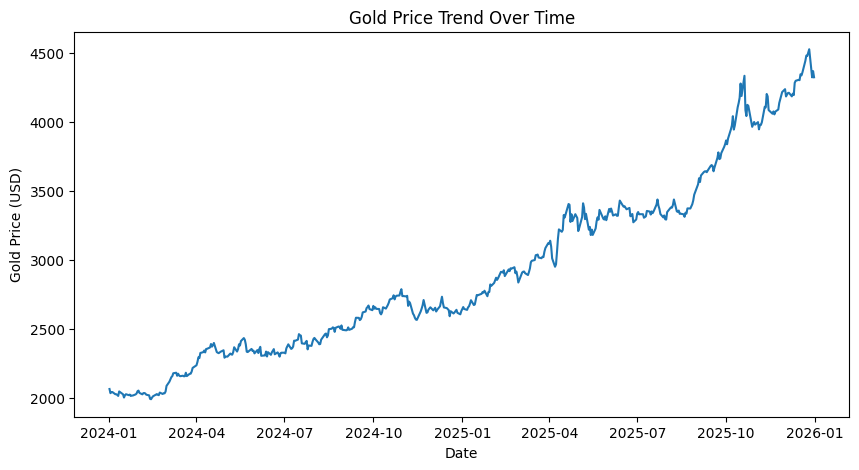

In [9]:
plt.figure(figsize=(10,5))
plt.plot(data["Date"], data["Gold"])
plt.title("Gold Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.show()

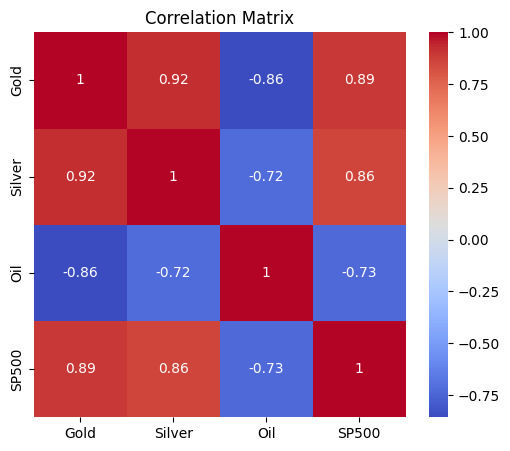

In [10]:

plt.figure(figsize=(6,5))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [11]:
data.set_index("Date", inplace=True)

In [12]:
data.head()

,Gold,Silver,Oil,SP500
Date,,,,
2024-01-02,2064.399902,23.733000,70.379997,4742.830078
2024-01-03,2034.199951,22.945999,72.699997,4704.810059
2024-01-04,2042.300049,22.989000,72.190002,4688.680176
2024-01-05,2042.400024,23.122000,73.809998,4697.240234
2024-01-08,2026.599976,23.120001,70.769997,4763.540039


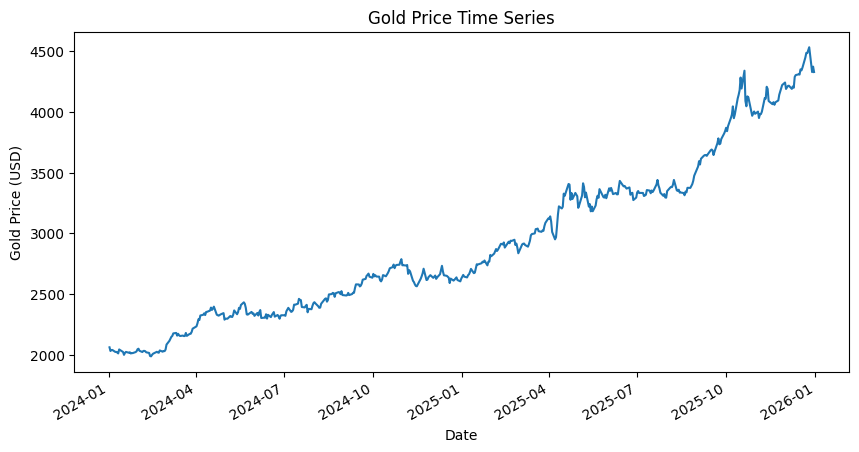

In [13]:
import matplotlib.pyplot as plt

data["Gold"].plot(figsize=(10,5), title="Gold Price Time Series")
plt.ylabel("Gold Price (USD)")
plt.show()

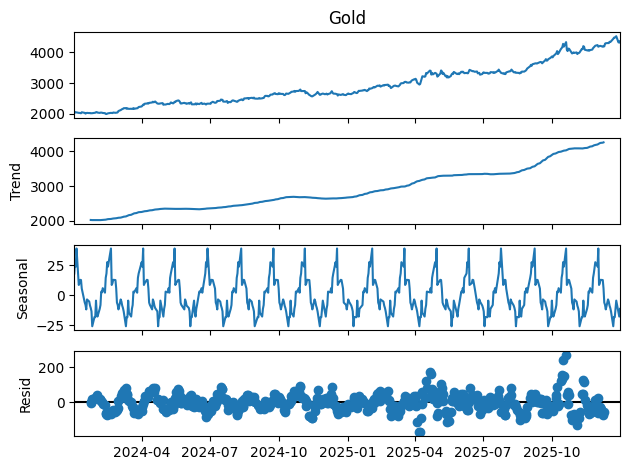

In [14]:
#TIME SERIES DECOMPOSITION

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(data["Gold"], model="additive", period=30)
result.plot()
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data["Gold"])

print("ADF Statistic:", round(result[0],2))
print("p-value:", result[1])

ADF Statistic: 0.67
p-value: 0.9892615216663311


In [16]:
from statsmodels.tsa.stattools import kpss
kpss_test = kpss(data['Gold'],regression='ct')

print("KPSS Test Results: ")
print(f'kpss Statistics: {round(kpss_test[0],2)}')
print(f'P Value: {round(kpss_test[1],2)}')

KPSS Test Results: 
kpss Statistics: 0.65
P Value: 0.01


In [17]:
data["Gold_diff"] = data["Gold"].diff()
data = data.dropna()

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data["Gold_diff"])

print("ADF Statistic:", round(result[0],2))
print("p-value:", result[1])

ADF Statistic: -24.75
p-value: 0.0


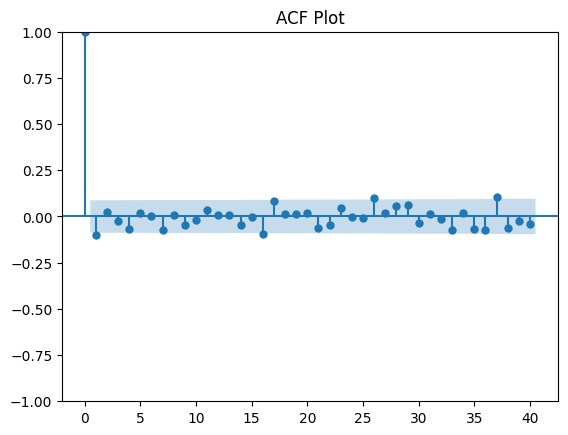

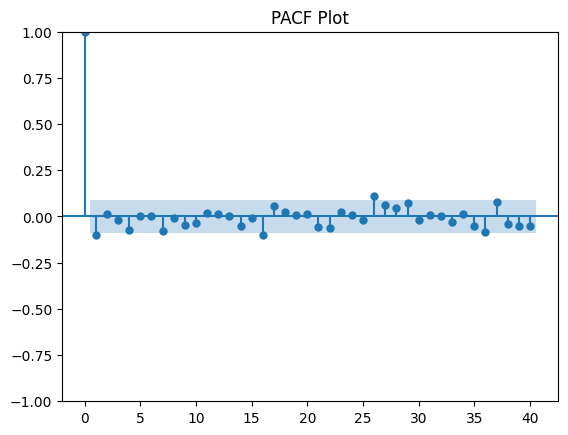

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(data["Gold_diff"], lags=40)
plt.title("ACF Plot")
plt.show()

plot_pacf(data["Gold_diff"], lags=40)
plt.title("PACF Plot")
plt.show()


In [20]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data["Gold"], order=(0,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   Gold   No. Observations:                  503
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -2529.343
Date:                Fri, 13 Mar 2026   AIC                           5060.686
Time:                        15:29:38   BIC                           5064.905
Sample:                             0   HQIC                          5062.341
                                - 503                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1392.9646     42.559     32.730      0.000    1309.551    1476.378
Ljung-Box (L1) (Q):                   5.24   Jarque-Bera (JB):              1180.25
Prob(Q):                              0.02   Pr

In [21]:
train_size = int(len(data) * 0.8)

train = data["Gold"][:train_size]
test = data["Gold"][train_size:]

In [22]:
model = ARIMA(train, order=(0,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

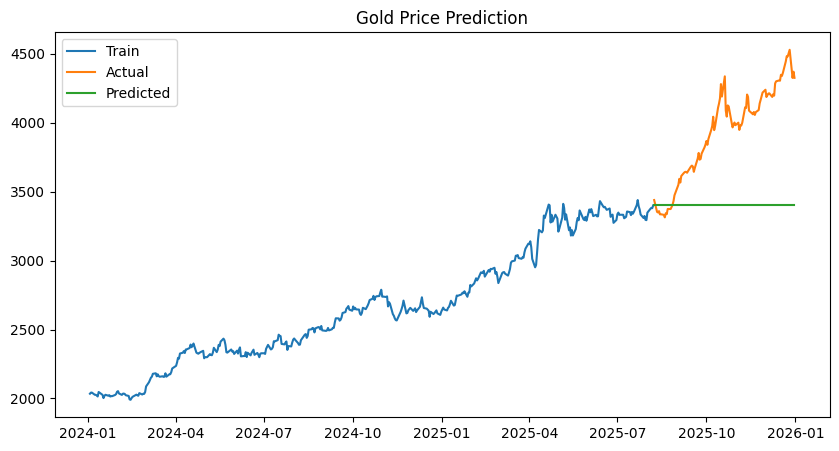

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast, label="Predicted")

plt.legend()
plt.title("Gold Price Prediction")
plt.show()

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    data["Gold"],
    exog=data[["Silver","Oil","SP500"]],
    order=(1,1,1)
)

model_fit = model.fit()

forecast = model_fit.predict(
    start=test.index[0],
    end=test.index[-1],
    exog=data[["Silver","Oil","SP500"]].iloc[len(train):]
)

In [25]:
forecast

Date
2025-08-08    3404.810046
2025-08-11    3417.099678
2025-08-12    3362.649041
2025-08-13    3358.012569
2025-08-14    3351.156644
                 ...     
2025-12-24    4512.309397
2025-12-26    4614.008800
2025-12-29    4370.520982
2025-12-30    4515.557628
2025-12-31    4199.430926
Name: predicted_mean, Length: 101, dtype: float64

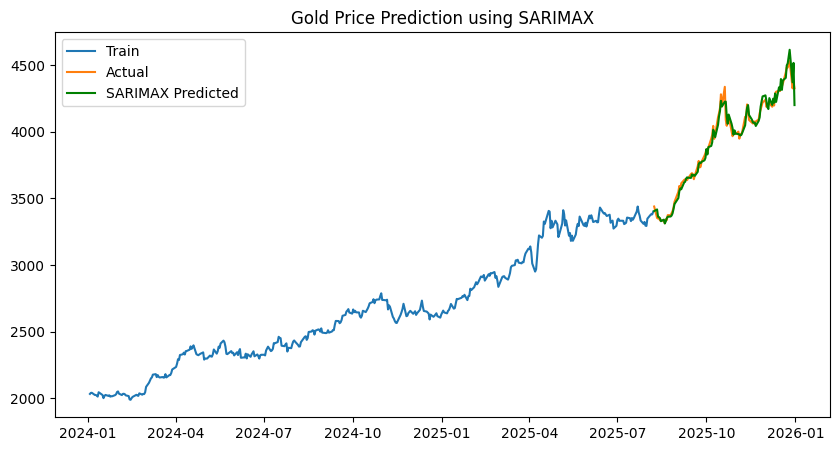

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast.index, forecast, label="SARIMAX Predicted", color="green")

plt.legend()
plt.title("Gold Price Prediction using SARIMAX")
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 29.948001464195322
RMSE: 40.93484907579074


## Saving The Model 

In [28]:
# Step 6 : Save the model
import joblib

joblib.dump(model_fit, "sarimax_model.pkl")

print("SARIMAX model saved successfully.")

SARIMAX model saved successfully.
